# Analiza danych obrazowych i multimedialnych, YOLO, Jan Milczarek, Julia Syzdół, Nazar Shcherbyna, Aleksandra Shuliakouskaya, Semestr: 2026L

# Omówienie metody YOLO
## Czym jest?
YOLO jest konwolucyjną siecią neuronową zaprezentowaną w 2015 w artykule "You Only Look Once: Unified, Real-Time Object Detection". Stworzył ją zespół w którego skład wchodzi: Joseph Redmon, Santosh Divvala, Ross Girshick oraz Ali Farhadi. Jest to sieć służąca oryginalnie do detekcji obiektów, w szczególności w czasie rzeczywistym, znajduje zastosowanie także w problemach klasyfikacji oraz segmentacji.

## Jak działa?
### Ogólna zasada działania
Tak jak sugeruje nazwa, YOLO działa dzięki przeprowadzeniu jednej ewaluacji obrazu wejściowego (lub klatki filmu w przypadku detekcji w czasie rzeczywistym). Odróżnia go to od innych modeli opierających się na oknach przesuwnych bądź analizie regionów w obrazie i jest jednym z jego największych atutów ponieważ pozwala modelowi widzieć obiekty w pewnym szerszym kontekście zdjęcia (pozwala to uniknąć chociażby fałszywych detekcji na obszarach tła).
### Budowa sieci
Architektura pierwszej wersji sieci była inspirowana GoogLeNet i składała się z 24 warstw konwolucyjnych, 2 warstw w pełni połączonych oraz 4 warstw Maxpool. Sieć była trenowana na obrazach o rozdzielczości 448x448 pikseli i właśnie taka rozdzielczość jest wymagana na warstwie wejściowej. Tensor wyjściowy sieci ma wymiary zdefiniowane wzorem: *S \* S * (B \* 5 + C)* gdzie *S* jest wymiarem siatki użytej do podziału obrazu wejściowego, *B* jest ilością bounding boxów na oczko siatki, a C jest ilością klas.
## Przydatne linki
Oryginalny papier: https://arxiv.org/abs/1506.02640  
Strona Josepha Redmona: https://pjreddie.com/yolo/  
Najnowszy model YOLO: https://docs.ultralytics.com/models/yolo26#overview


# Omówienie wykorzystanych implementacji
W eksperymentach korzystaliśmy z trzech najnowszych implementacji sieci YOLO, 8, 11 oraz 26. Wszystkie one udostępniane są przez firmę Ultralytics (link podany wyżej). Framework ultralytics jest bardzo wysokopoziomowy, jako użytkownik końcowy modyfikujemy w zasadzie wyłącznie parametry wejściowe modelu, takie jak optymalizator, liczba epok treningu, czułość detekcji (jakie prawdopodobieństwo wsytąpienia obiektu traktujemy jako wykrycie).

## Jak zainstalować ultralytics?
Ultralytics można zainstalować w środowisku Jupyter Notebook używając managera pakietów pip. Jeżeli chcemy używać kart graficznych (na przykład do szybszego treningu) konieczne jest także przygotowanie sterowników CUDA i CUDnn. W google Colab wystarczy natomiast:

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.2 MB/s eta 0:00:00


## Zalety ultralytics
Ultralytics nie wymaga wielu dodatkowych zależności i w środowiskach ze skonfigurowanymi sterownikami kart graficznych wystarczy zainstalować go z pythonowego managera pakietów. Framework jest bardzo prosty w obsłudze i nieustannie wspierany, regularnie wypuszczane są nowe modele YOLO. Ma rozbudowaną dokumentację na własnej stronie oraz w formie tutoriali na YouTube.

# Działanie YOLO
Wyniki przeklejone z notatnika eksperymentalnego i zmodyfikowane by nie używać zdjęć przechowywanych lokalnie. Jak widać właściwa detekcja ogranicza się do dwóch linijek kodu, załadowania modelu i predykcji z ustalonymi parametrami. Tutaj załadowaliśmy wersję jedenastą nano (najmniejszy i najszybszy wariant). Model radzi sobie całkiem dobrze z obiektami klas występujących w COCO (ludzie, rowery, auta itd.). Ze względu na swoją szybkość, modelu można używać także w trybie "track" do detekcji w formacie video.

WARNING ⚠️ Download failure, retrying 1/3 https://upload.wikimedia.org/wikipedia/commons/2/28/2025_-_free_download_photo_of_biking_people,_waiting_for_the_green_street_light_at_the_crossing_Elandsgracht_-_Kinkerstraat_&_Marnixstraat_in_Amsterdam_city._People_in_the_street_on_A_Grey_day_in_February._Street_photography_free_image.tif... HTTP Error 403: Forbidden


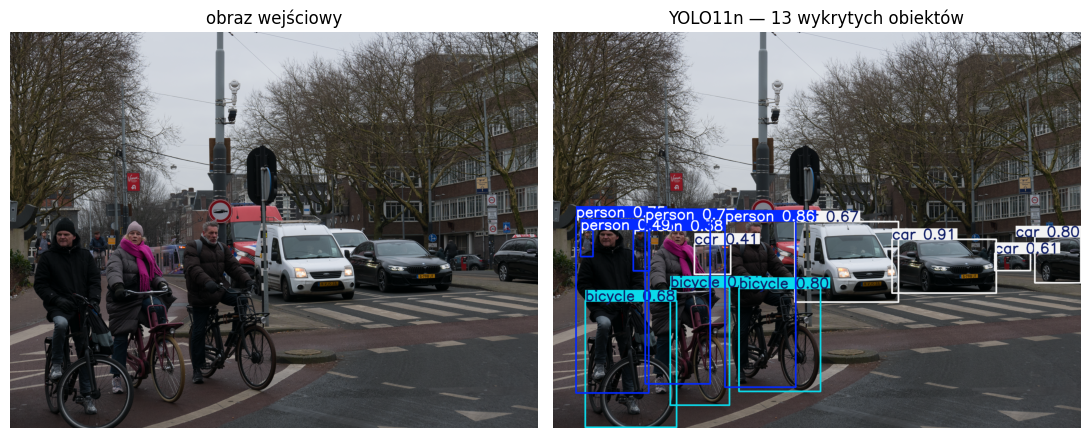

Wykryte obiekty:  car ×5    person ×5    bicycle ×3


In [ ]:
import warnings; warnings.filterwarnings("ignore")
import requests
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display
import yaml
from ultralytics import YOLO
from io import BytesIO
from PIL import Image

img = "https://upload.wikimedia.org/wikipedia/commons/2/28/2025_-_free_download_photo_of_biking_people%2C_waiting_for_the_green_street_light_at_the_crossing_Elandsgracht_-_Kinkerstraat_%26_Marnixstraat_in_Amsterdam_city._People_in_the_street_on_A_Grey_day_in_February._Street_photography_free_image.tif"
model = YOLO("yolo11n.pt")
res = model.predict(img, conf=0.35, device="cpu", verbose=False)[0]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
ax[0].imshow(res.orig_img[..., ::-1]); ax[0].set_title("obraz wejściowy")
ax[1].imshow(res.plot()[..., ::-1])
ax[1].set_title(f"YOLO11n — {len(res.boxes)} wykrytych obiektów")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

vc = pd.Series([model.names[int(c)] for c in res.boxes.cls]).value_counts()
print("Wykryte obiekty:  " + "    ".join(f"{k} ×{v}" for k, v in vc.items()))

In [ ]:
model = YOLO("yolo11n.pt")
results = model.track("https://www.youtube.com/watch?v=u8vaVWSOlgM", show=True)


1/1: https://www.youtube.com/watch?v=u8vaVWSOlgM... Success ✅ (6301 frames of shape 1920x1080 at 50.00 FPS)

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

0: 384x640 1 clock, 550.4ms
0: 384x640 (no detections), 383.5ms
0: 384x640 1 car, 409.8ms
0: 384x640 1 car, 331.1ms


KeyboardInterrupt: 

# Analiza krytyczna
W ramach przeprowadzanych eksperymentów porównywaliśmy międzyinnymi metryki czasowe (czas potrzebny na przetworzenie obrazu) oraz jakościowe (mAP@50 i mAP@50-95).
## Precyzja
Pomiędzy wersjami zaobserwowano różnice na poziomie błędu pomiarowego. Nie zmieniały się znacząco pomiędzy rozmiarami modelu.

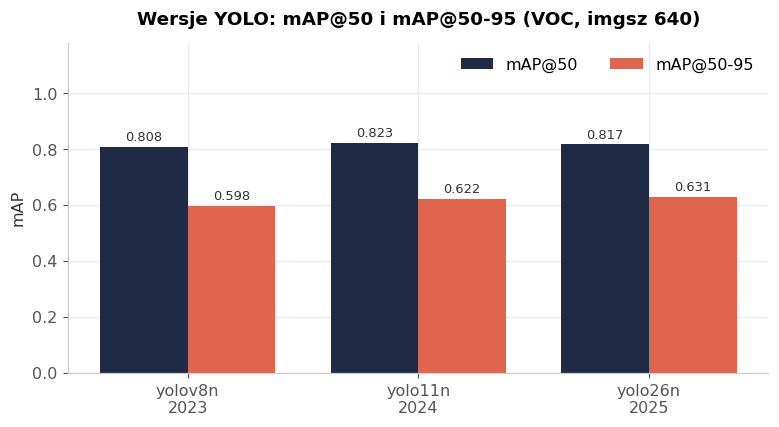

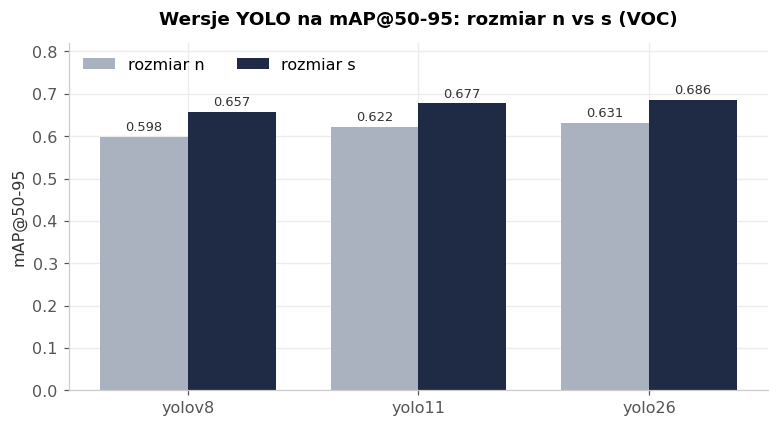

## Czas detekcji i precyzja w kontekście rozmiaru modelu
Ultralytics udostępnia modele w rozmiarach n (nano), s (small), m (medium), l (large) oraz x (extra large), im większy model tym większa precyzja detekcji, kosztem czasu działania.

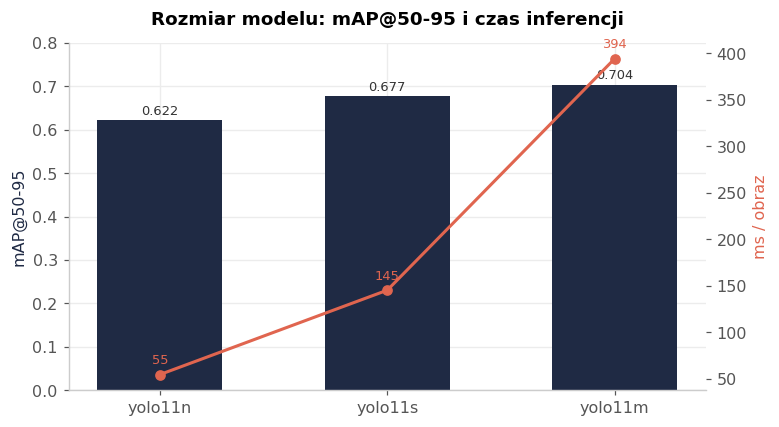

## Wpływ rozdzielczości wejścia na precyzję
Modele ultralytics domyślnie automatycznie przeskalowują obrazy wejściowe do rozmiaru 640x640 pikseli (zarówno przy treningu jak i detekcji). Co za tym idzie, przekazywanie zdjęć mniejszych bądź większych do modelu kończy się utratą jakości (rozmyciami, rozpikselowaniem) i tym samym utratą precyzji w detekcji. Obrazy duże są dodatkowo bardziej kosztowne obliczeniowo.

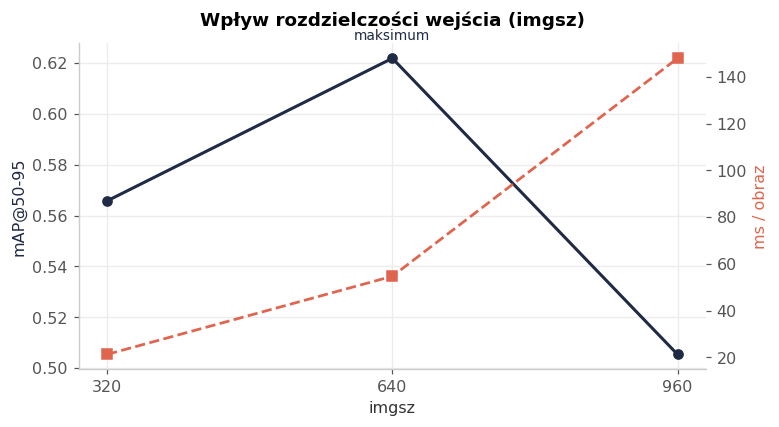

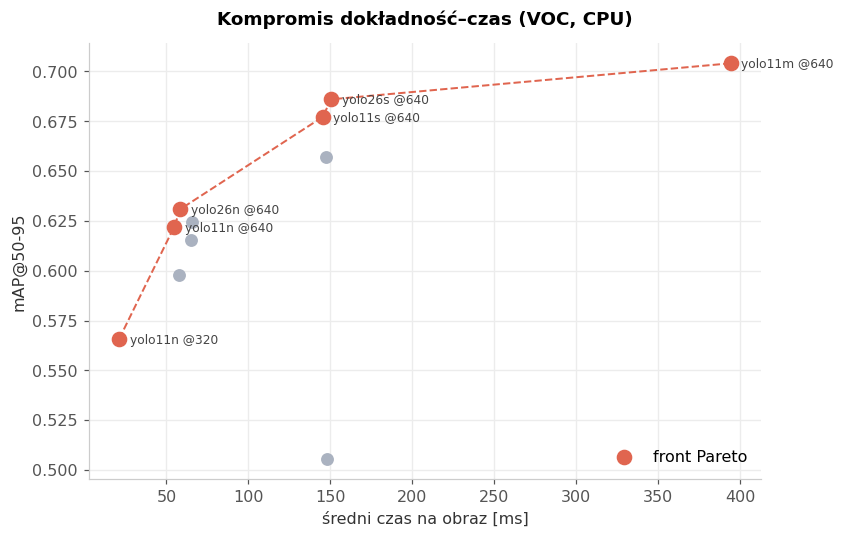

# Wnioski
1. Podczas korzystania z YOLO warto zastanowić się nad tym jakiego rozmiaru modelu używamy. Korzystanie z modeli większych niż m w zastosowaniach czasu rzeczywistego może nie zadziałać. Jeżeli precyzja jest dla nas najważniejszym współczynnikiem, warto rozważyć większe modele.
2. Należy unikać przeskalowywania obrazów wejściowych, ponieważ skutkuje to utratą jakości zdjęć oraz tym samym precyzji detekcji.
3. Jeżeli nie jest to konieczne nie warto jest za wszelką cenę używać najnowszych dostępnych modeli, ponieważ ich osiągi nie są znacząco lepsze z wersji na wersję.

##